# 02 - Autoencoder (não supervisionado) — metodologia corrigida

Modelo 1. Autoencoder convolucional treinado **só com imagens normais**.

> **Correção vs versão antiga:** antes o melhor modelo era escolhido pela *train
> loss* e não havia validação. Agora dividimos `train/good` em **treino +
> validação** e guardamos o checkpoint com a **melhor val loss** — exatamente
> como em `scripts/train_autoencoder_bottle.py`. Sem olhar para o teste.

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

import torch
from utils import set_seed, get_device

set_seed(42)
device = get_device()
print("device:", device)

device: cuda


## 1. Dados — split treino/validação (só imagens normais)

`bottle/train/good` é dividido de forma determinística: a maioria para treino, o
resto para **validação** (usada para escolher o melhor modelo).

In [2]:
from bottle_protocol import bottle_train_good_paths, split_train_validation_good
from dataset import criar_loader_de_paths

all_good = bottle_train_good_paths()
train_paths, val_paths = split_train_validation_good(all_good, val_fraction=0.2, seed=42)

train_loader = criar_loader_de_paths(train_paths, batch_size=16, tamanho_imagem=256, shuffle=True)
val_loader = criar_loader_de_paths(val_paths, batch_size=16, tamanho_imagem=256, shuffle=False)

print(f"Treino: {len(train_paths)} normais | Validação: {len(val_paths)} normais")

Treino: 167 normais | Validação: 42 normais


## 2. Treino com validação (guarda o melhor pela val loss)

In [3]:
from autoencoder import Autoencoder
from treino import treinar_autoencoder_com_validacao

modelo = Autoencoder()
caminho_modelo = ROOT / "models" / "autoencoder_bottle_best.pth"

historico = treinar_autoencoder_com_validacao(
    modelo=modelo,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=50,
    lr=1e-3,
    device=device,
    caminho_modelo=str(caminho_modelo),
)
print("Melhor modelo guardado em:", caminho_modelo)

Epoch 1/50 - train loss: 1.9768 | val loss: 1.6403 | best val: 1.6403


Epoch 10/50 - train loss: 0.0539 | val loss: 0.0579 | best val: 0.0579


Epoch 20/50 - train loss: 0.0284 | val loss: 0.0283 | best val: 0.0283


Epoch 30/50 - train loss: 0.0212 | val loss: 0.0219 | best val: 0.0219


Epoch 40/50 - train loss: 0.0167 | val loss: 0.0174 | best val: 0.0174


Epoch 50/50 - train loss: 0.0147 | val loss: 0.0155 | best val: 0.0152

Treino concluido. Melhor val loss: 0.0152
Melhor modelo guardado em: C:\Users\maria\Desktop\projeto\models\autoencoder_bottle_best.pth


## 3. Curva de treino (train vs validation loss)

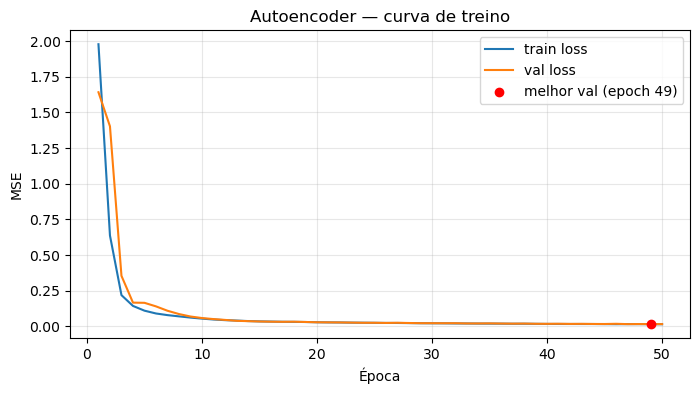

In [4]:
epochs = [h["epoch"] for h in historico]
train_loss = [h["train_loss"] for h in historico]
val_loss = [h["val_loss"] for h in historico]

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss, label="train loss")
plt.plot(epochs, val_loss, label="val loss")
melhor = int(np.argmin(val_loss))
plt.scatter([epochs[melhor]], [val_loss[melhor]], color="red", zorder=5,
            label=f"melhor val (epoch {epochs[melhor]})")
plt.xlabel("Época"); plt.ylabel("MSE"); plt.title("Autoencoder — curva de treino")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 4. Exemplos de reconstrução

Original / reconstrução / mapa de erro (`hot`). O erro de reconstrução é o score
de anomalia. As métricas de localização ao pixel ficam no notebook 05.

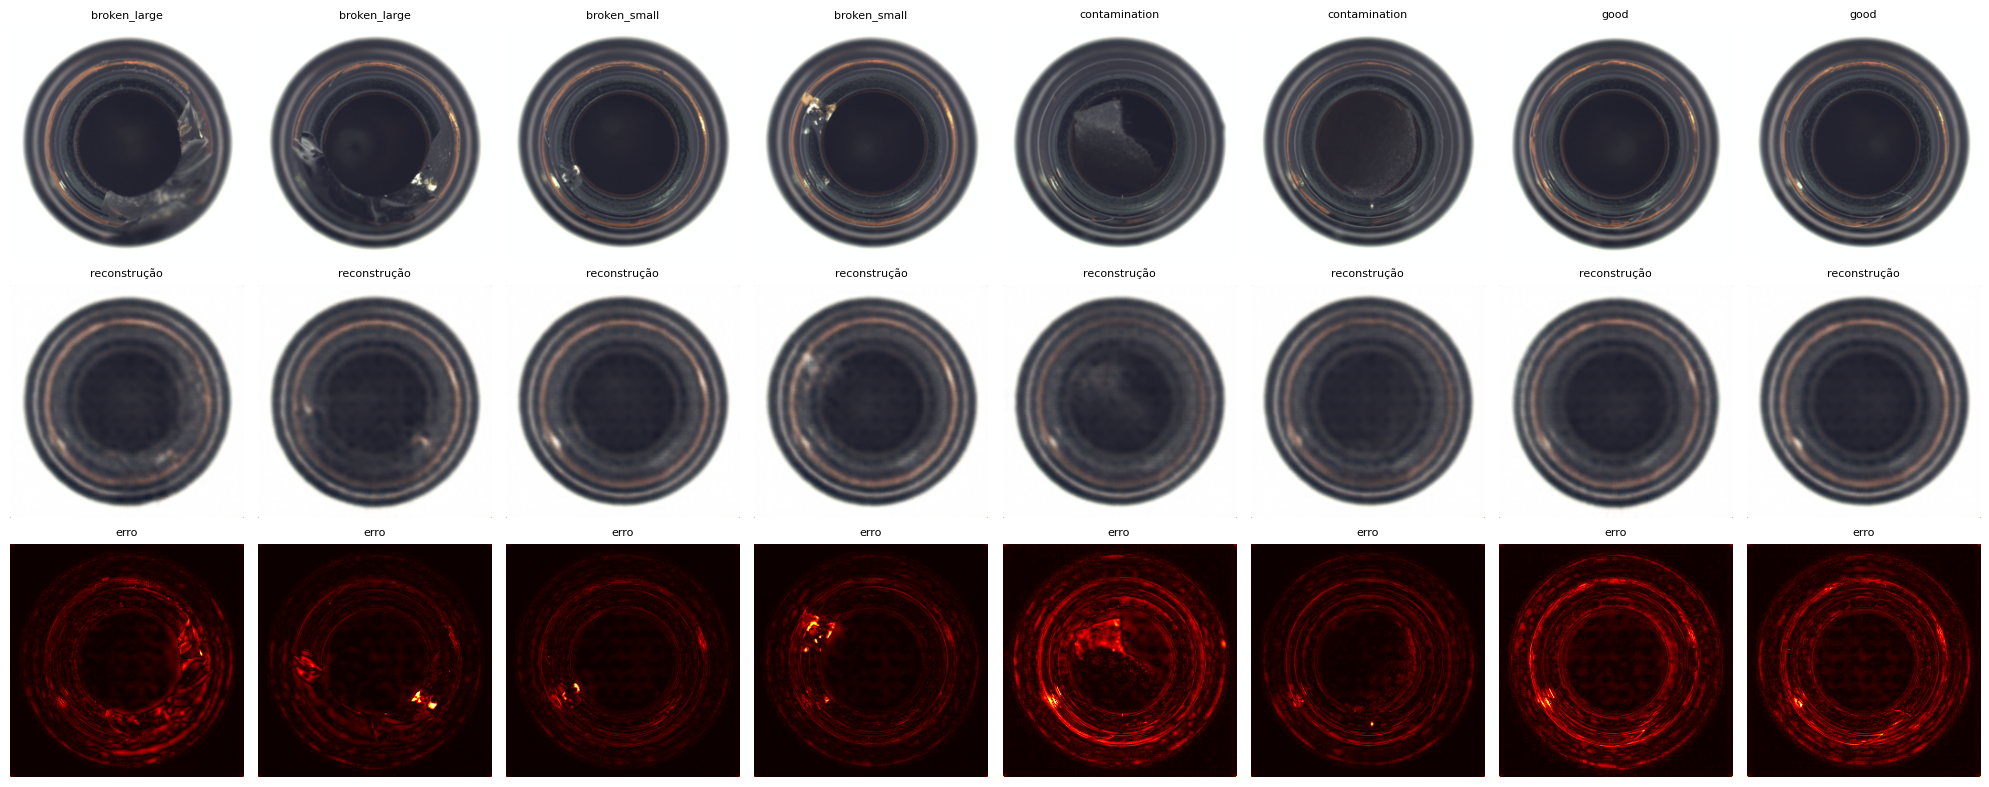

In [5]:
from bottle_protocol import bottle_test_records
from torchvision import transforms
from PIL import Image

mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
def desnorm(t):
    img = t.detach().cpu().numpy().transpose(1, 2, 0) * std + mean
    return np.clip(img, 0, 1)

modelo.eval()
tf = transforms.Compose([
    transforms.Resize((256, 256)), transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist()),
])

registos = bottle_test_records()
por_tipo = {}
for r in registos:
    por_tipo.setdefault(r.defect_type, []).append(r)
escolhidos = [r for lista in por_tipo.values() for r in lista[:2]][:8]

fig, axes = plt.subplots(3, len(escolhidos), figsize=(2.5 * len(escolhidos), 8))
for i, r in enumerate(escolhidos):
    x = tf(Image.open(r.path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        rec = modelo(x)
    erro = torch.abs(x - rec).mean(dim=1).squeeze().cpu().numpy()
    axes[0, i].imshow(desnorm(x.squeeze(0))); axes[0, i].set_title(r.defect_type, fontsize=8); axes[0, i].axis("off")
    axes[1, i].imshow(desnorm(rec.squeeze(0))); axes[1, i].set_title("reconstrução", fontsize=8); axes[1, i].axis("off")
    axes[2, i].imshow(erro, cmap="hot"); axes[2, i].set_title("erro", fontsize=8); axes[2, i].axis("off")
plt.tight_layout(); plt.show()